In [1]:
!pip install -q shap

In [2]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap

from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
df = pd.read_csv("heart.csv")

# Os nomes abaixo são usados no código e nas tabelas exibidas.
nomes_colunas = {
    "Age": "Idade",
    "Sex": "Sexo",
    "ChestPainType": "Dor_Peito",
    "RestingBP": "PA_Rep",
    "Cholesterol": "Colest",
    "FastingBS": "Glic_Jej",
    "RestingECG": "ECG_Rep",
    "MaxHR": "FC_Max",
    "ExerciseAngina": "Ang_Ex",
    "Oldpeak": "Dep_ST",
    "ST_Slope": "Inc_ST",
    "HeartDisease": "Doenc_Card"
}

df = df.rename(columns=nomes_colunas)

df_exibicao = df.copy()

traducoes_exibicao = {
    "Sexo": {"M": "Masculino", "F": "Feminino"},
    "Dor_Peito": {
        "ASY": "Assintomática",
        "NAP": "Não anginosa",
        "ATA": "Atípica",
        "TA": "Típica"
    },
    "ECG_Rep": {
        "Normal": "Normal",
        "ST": "Alteração ST-T",
        "LVH": "Hipertrofia ventricular esquerda"
    },
    "Ang_Ex": {"N": "Não", "Y": "Sim"},
    "Inc_ST": {"Up": "Ascendente", "Flat": "Plana", "Down": "Descendente"}
}

for coluna, mapa in traducoes_exibicao.items():
    df_exibicao[coluna] = df_exibicao[coluna].replace(mapa)

print("Dimensões do conjunto de dados:", df.shape)
display(df_exibicao.head())


Dimensões do conjunto de dados: (918, 12)


,Idade,Sexo,Dor_Peito,PA_Rep,Colest,Glic_Jej,ECG_Rep,FC_Max,Ang_Ex,Dep_ST,Inc_ST,Doenc_Card
0,40,Masculino,Atípica,140,289,0,Normal,172,Não,0.0,Ascendente,0
1,49,Feminino,Não anginosa,160,180,0,Normal,156,Não,1.0,Plana,1
2,37,Masculino,Atípica,130,283,0,Alteração ST-T,98,Não,0.0,Ascendente,0
3,48,Feminino,Assintomática,138,214,0,Normal,108,Sim,1.5,Plana,1
4,54,Masculino,Não anginosa,150,195,0,Normal,122,Não,0.0,Ascendente,0


In [4]:
print("Valores ausentes por coluna:")
display(df.isnull().sum())

print("\nDistribuição da variável-alvo:")
display(df["Doenc_Card"].value_counts())

print("\nDistribuição percentual da variável-alvo:")
display(df["Doenc_Card"].value_counts(normalize=True) * 100)


Valores ausentes por coluna:


,0
Idade,0
Sexo,0
Dor_Peito,0
PA_Rep,0
Colest,0
Glic_Jej,0
ECG_Rep,0
FC_Max,0
Ang_Ex,0
Dep_ST,0



Distribuição da variável-alvo:


,count
Doenc_Card,
1,508
0,410



Distribuição percentual da variável-alvo:


,proportion
Doenc_Card,
1,55.337691
0,44.662309


In [5]:
X = df.drop(columns=["Doenc_Card"])
y = df["Doenc_Card"].astype(int)

print("Formato das entradas:", X.shape)
print("Formato da saída:", y.shape)
print("Colunas:", list(X.columns))


Formato das entradas: (918, 11)
Formato da saída: (918,)
Colunas: ['Idade', 'Sexo', 'Dor_Peito', 'PA_Rep', 'Colest', 'Glic_Jej', 'ECG_Rep', 'FC_Max', 'Ang_Ex', 'Dep_ST', 'Inc_ST']


In [6]:
colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Colunas numéricas:", colunas_numericas)
print("Colunas categóricas:", colunas_categoricas)


Colunas numéricas: ['Idade', 'PA_Rep', 'Colest', 'Glic_Jej', 'FC_Max', 'Dep_ST']
Colunas categóricas: ['Sexo', 'Dor_Peito', 'ECG_Rep', 'Ang_Ex', 'Inc_ST']


In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print("Treino:", X_train_raw.shape)
print("Teste:", X_test_raw.shape)

Treino: (734, 11)
Teste: (184, 11)


In [8]:
# Padroniza as colunas numéricas e transforma as categóricas em variáveis binárias.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), colunas_categoricas)
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Nomes internos gerados pelo pré-processador.
feature_names_originais = preprocessor.get_feature_names_out()

# Nomes curtos usados somente na apresentação dos gráficos e do SHAP.
mapa_features = {
    "num__Idade": "Idade",
    "num__PA_Rep": "PA_Rep",
    "num__Colest": "Colest",
    "num__Glic_Jej": "Glic_Jej",
    "num__FC_Max": "FC_Max",
    "num__Dep_ST": "Dep_ST",
    "cat__Sexo_F": "Sexo_F",
    "cat__Sexo_M": "Sexo_M",
    "cat__Dor_Peito_ASY": "Dor_Assint",
    "cat__Dor_Peito_NAP": "Dor_NAng",
    "cat__Dor_Peito_ATA": "Dor_Atip",
    "cat__Dor_Peito_TA": "Dor_Tip",
    "cat__ECG_Rep_Normal": "ECG_Norm",
    "cat__ECG_Rep_ST": "ECG_ST",
    "cat__ECG_Rep_LVH": "ECG_HVE",
    "cat__Ang_Ex_N": "Ang_Ex_N",
    "cat__Ang_Ex_Y": "Ang_Ex_S",
    "cat__Inc_ST_Up": "Inc_ST_Asc",
    "cat__Inc_ST_Flat": "Inc_ST_Plana",
    "cat__Inc_ST_Down": "Inc_ST_Desc"
}

feature_names = np.array([
    mapa_features.get(nome, nome.replace("num__", "").replace("cat__", ""))
    for nome in feature_names_originais
])

print("Quantidade final de características:", X_train.shape[1])
print("Formato X_train:", X_train.shape)
print("Formato X_test:", X_test.shape)
print("Nomes curtos das características:", list(feature_names))


Quantidade final de características: 20
Formato X_train: (734, 20)
Formato X_test: (184, 20)
Nomes curtos das características: [np.str_('Idade'), np.str_('PA_Rep'), np.str_('Colest'), np.str_('Glic_Jej'), np.str_('FC_Max'), np.str_('Dep_ST'), np.str_('Sexo_F'), np.str_('Sexo_M'), np.str_('Dor_Assint'), np.str_('Dor_Atip'), np.str_('Dor_NAng'), np.str_('Dor_Tip'), np.str_('ECG_HVE'), np.str_('ECG_Norm'), np.str_('ECG_ST'), np.str_('Ang_Ex_N'), np.str_('Ang_Ex_S'), np.str_('Inc_ST_Desc'), np.str_('Inc_ST_Plana'), np.str_('Inc_ST_Asc')]


In [9]:
classes = np.unique(y_train)
pesos = class_weight.compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, pesos))
print("Pesos das classes:", class_weights)

Pesos das classes: {np.int64(0): np.float64(1.1189024390243902), np.int64(1): np.float64(0.9039408866995073)}


In [10]:
def construir_modelo(formato_entrada):
    modelo = models.Sequential([
        layers.Input(shape=(formato_entrada,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return modelo

model = construir_modelo(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,089 (27.69 KB)

 Trainable params: 7,089 (27.69 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
parada_antecipada = callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)
reducao_taxa = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1
)

history = model.fit(
    X_train, y_train, epochs=100, batch_size=32, validation_split=0.20,
    callbacks=[parada_antecipada, reducao_taxa], class_weight=class_weights, verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.5860 - loss: 0.6818 - precision: 0.5908 - recall: 0.7981 - val_accuracy: 0.6054 - val_loss: 0.6720 - val_precision: 0.6161 - val_recall: 0.8214 - learning_rate: 1.0000e-04
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6491 - loss: 0.6664 - precision: 0.6312 - recall: 0.8665 - val_accuracy: 0.6871 - val_loss: 0.6587 - val_precision: 0.6759 - val_recall: 0.8690 - learning_rate: 1.0000e-04
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7019 - loss: 0.6542 - precision: 0.6705 - recall: 0.8975 - val_accuracy: 0.7007 - val_loss: 0.6447 - val_precision: 0.6852 - val_recall: 0.8810 - learning_rate: 1.0000e-04
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6934 - loss: 0.6404 - precision: 0.6614 - recall: 0.9037 - val_accuracy: 0.7211 - val_loss: 0.6289 - val_precision: 0.7048 - val_recall: 0.8810 - learning_rate: 1.0000e-04
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 106m

In [12]:
model.save("heart_disease_classifier.keras")
joblib.dump(preprocessor, "heart_disease_preprocessor.pkl")
joblib.dump(feature_names, "heart_disease_feature_names.pkl")
print("Modelo, pré-processador e nomes das características salvos com sucesso.")

Modelo, pré-processador e nomes das características salvos com sucesso.


In [13]:
resultados = model.evaluate(X_test, y_test, verbose=0)
for nome, valor in zip(model.metrics_names, resultados):
    print(f"{nome}: {valor:.4f}")

loss: 0.2952
compile_metrics: 0.9130


In [14]:
y_pred_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("=" * 60)

print(classification_report(
    y_test, y_pred,
    target_names=["Sem doença cardíaca", "Com doença cardíaca"],
    digits=4, zero_division=0
))

print("Acurácia:", round(accuracy_score(y_test, y_pred), 4))
print("Precisão:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1:", round(f1_score(y_test, y_pred, zero_division=0), 4))


RELATÓRIO DE CLASSIFICAÇÃO
                     precision    recall  f1-score   support

Sem doença cardíaca     0.9024    0.9024    0.9024        82
Com doença cardíaca     0.9216    0.9216    0.9216       102

           accuracy                         0.9130       184
          macro avg     0.9120    0.9120    0.9120       184
       weighted avg     0.9130    0.9130    0.9130       184

Acurácia: 0.913
Precisão: 0.9216
Recall: 0.9216
F1: 0.9216


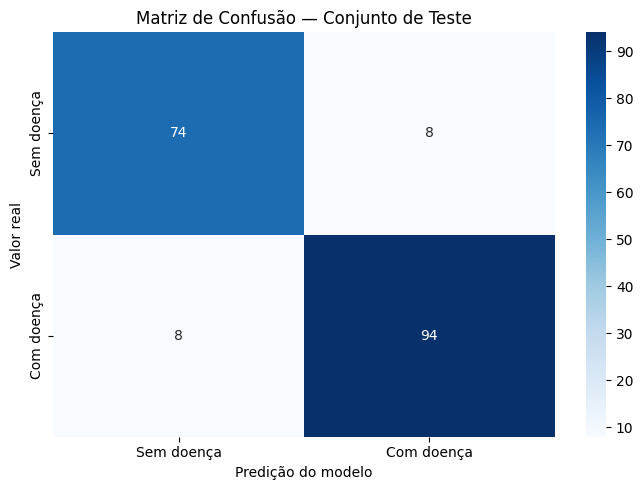

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Sem doença", "Com doença"],
    yticklabels=["Sem doença", "Com doença"]
)
plt.title("Matriz de Confusão — Conjunto de Teste")
plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()


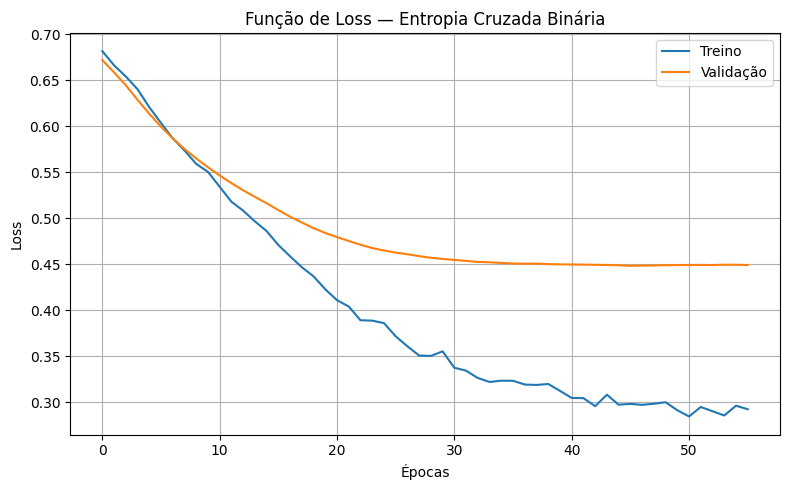

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Função de Loss — Entropia Cruzada Binária")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


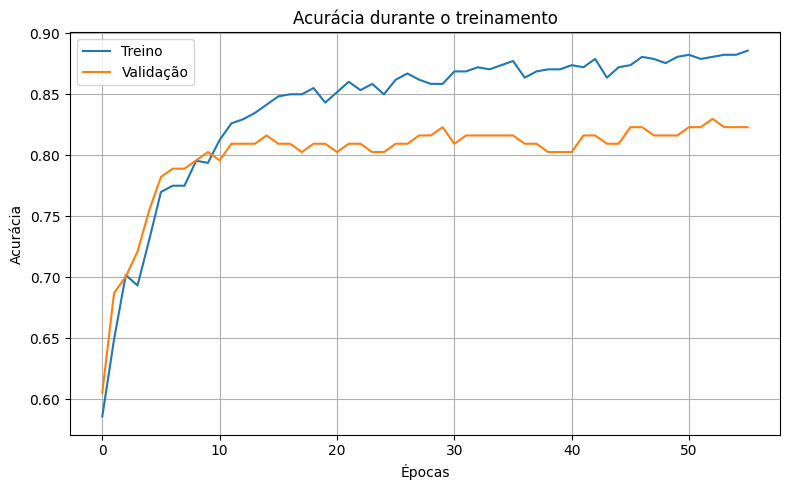

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

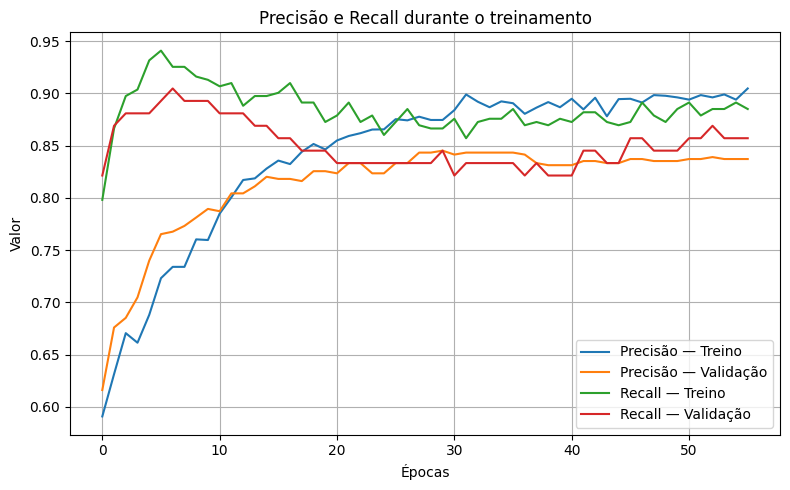

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["precision"], label="Precisão — Treino")
plt.plot(history.history["val_precision"], label="Precisão — Validação")
plt.plot(history.history["recall"], label="Recall — Treino")
plt.plot(history.history["val_recall"], label="Recall — Validação")
plt.title("Precisão e Recall durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
background_size = min(100, X_train.shape[0])
background = X_train[:background_size]
explain_size = min(200, X_test.shape[0])
X_explain = X_test[:explain_size]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(X_explain)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print("Formato dos valores SHAP:", shap_values.shape)
print("Formato das amostras explicadas:", X_explain.shape)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(184, 20))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 20))']
  warnings.warn(msg)


Formato dos valores SHAP: (184, 20)
Formato das amostras explicadas: (184, 20)


/tmp/ipykernel_1348/1733670227.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


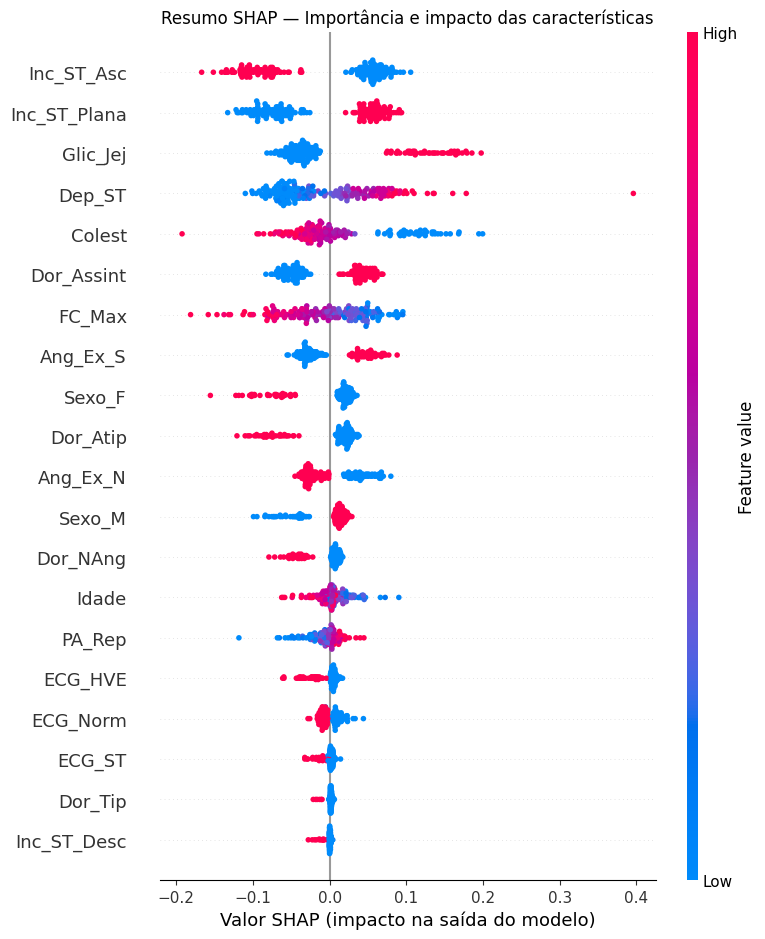

In [20]:
plt.figure(figsize=(9, 10))
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    show=False
)
plt.title("Resumo SHAP — Importância e impacto das características")
plt.xlabel("Valor SHAP (impacto na saída do modelo)")
plt.tight_layout()
plt.show()


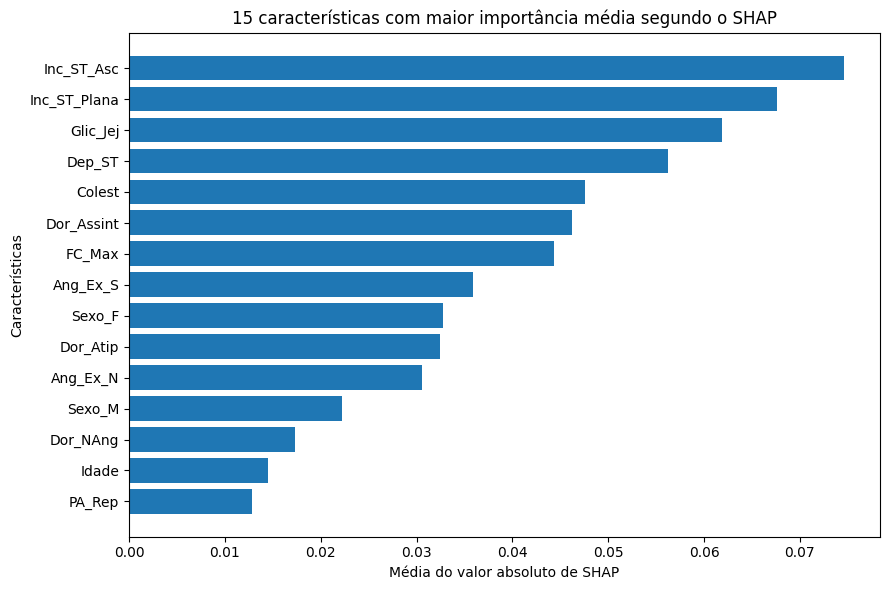

In [21]:
importancias_shap = np.abs(shap_values).mean(axis=0)
ordem = np.argsort(importancias_shap)[-15:]

plt.figure(figsize=(9, 6))
plt.barh(
    np.array(feature_names)[ordem],
    importancias_shap[ordem]
)
plt.title("15 características com maior importância média segundo o SHAP")
plt.xlabel("Média do valor absoluto de SHAP")
plt.ylabel("Características")
plt.tight_layout()
plt.show()


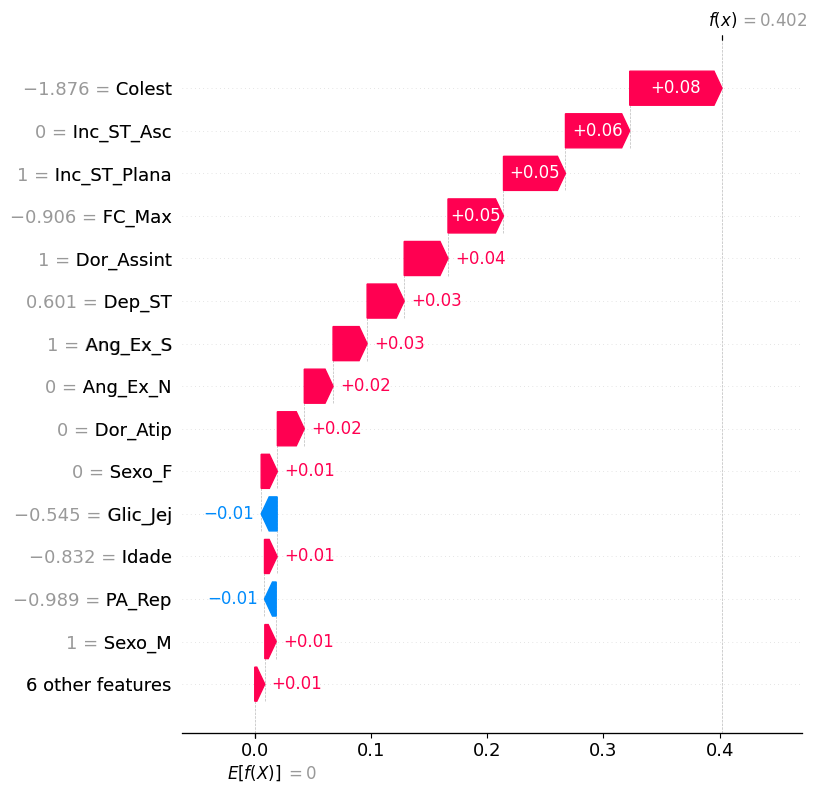

In [22]:
indice_amostra = 0

shap_exp = shap.Explanation(
    values=shap_values[indice_amostra],
    base_values=float(np.asarray(explainer.expected_value).reshape(-1)[0])
        if hasattr(explainer, "expected_value") else 0.0,
    data=X_explain[indice_amostra],
    feature_names=feature_names
)

shap.plots.waterfall(shap_exp, max_display=15)
